In [12]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [13]:
df = pd.read_csv("data.csv")

In [18]:
df.head()

,name,age,nationality,height_cm,weight_kgs,body_type,positions,acceleration,sprint_speed,agility,...,attacking_score,midfield_score,defensive_score,recommended_role,Pace,Shooting,Passing,Dribbling,Defending,Physical
0,I. Łasicki,23,Poland,182.88,69.9,Lean,CB,52,48,57,...,38.25,45.5,63.25,Defender,50.0,32.333333,35.333333,48.333333,62.666667,66.666667
1,Nuno Coelho,31,Portugal,182.88,76.2,Lean,"CDM,CB",66,50,64,...,48.75,65.5,71.75,Defender,58.0,47.666667,63.666667,62.000000,73.000000,68.666667
2,K. Kotsaris,22,Greece,185.42,74.8,Normal,GK,52,45,69,...,23.75,32.0,26.75,Midfielder,48.5,25.666667,30.000000,33.666667,13.666667,52.666667
3,B. Parker,32,South Africa,170.18,64.9,Normal,"CF,ST,LM,CAM",74,72,77,...,71.00,68.0,28.25,Attacker,73.0,69.666667,66.000000,74.333333,24.666667,65.000000
4,N. Dicko,26,Mali,172.72,73.9,Stocky,ST,89,86,79,...,66.50,61.5,43.25,Attacker,87.5,63.333333,59.333333,72.000000,31.000000,74.666667


In [19]:
df["Pace"] = (df["acceleration"] + df["sprint_speed"]) / 2
df["Shooting"] = (df["finishing"] + df["shot_power"] + df["long_shots"]) / 3
df["Passing"] = (df["short_passing"] + df["long_passing"] + df["vision"]) / 3
df["Dribbling"] = (df["dribbling"] + df["ball_control"] + df["agility"]) / 3
df["Defending"] = (df["standing_tackle"] + df["sliding_tackle"] + df["interceptions"]) / 3
df["Physical"] = (df["strength"] + df["stamina"] + df["balance"]) / 3

In [20]:
cluster_features = [
    "Pace", "Shooting", "Passing",
    "Dribbling", "Defending", "Physical"
]

X_cluster = df[cluster_features]

Feature Scaling

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [22]:
inertia = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

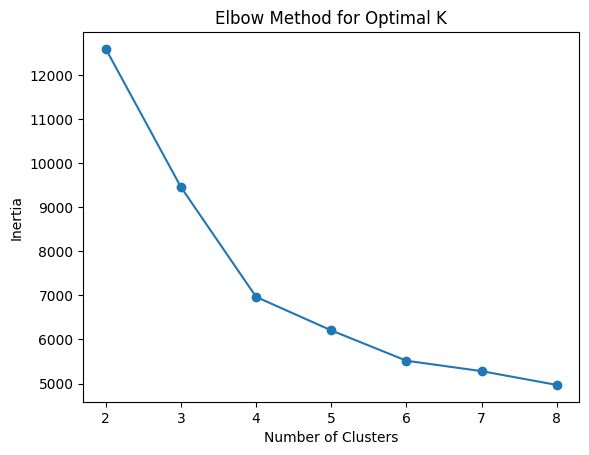

In [23]:
import matplotlib.pyplot as plt

plt.plot(range(2, 9), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

Train KMeans Model

In [24]:
kmeans = KMeans(n_clusters=5, random_state=42)
df["Archetype_Cluster"] = kmeans.fit_predict(X_scaled)

In [25]:
cluster_profiles = (
    df.groupby("Archetype_Cluster")[cluster_features]
    .mean()
    .round(1)
)

cluster_profiles

,Pace,Shooting,Passing,Dribbling,Defending,Physical
Archetype_Cluster,,,,,,
0,72.6,61.1,55.4,66.6,27.1,64.0
1,65.4,47.2,59.3,61.4,63.2,67.4
2,73.0,65.6,69.4,72.5,59.4,72.0
3,38.5,15.8,30.2,24.7,15.3,44.6
4,58.1,32.8,44.0,47.4,60.6,62.9


In [26]:
archetype_map = {
    0: "Goal Poacher",
    1: "Playmaker",
    2: "Defensive Anchor",
    3: "Pace Winger",
    4: "Box-to-Box Midfielder"
}

df["Player_Archetype"] = df["Archetype_Cluster"].map(archetype_map)

In [27]:
import joblib

joblib.dump(kmeans, "player_archetype_kmeans.joblib")
joblib.dump(scaler, "archetype_scaler.joblib")
joblib.dump(cluster_features, "archetype_features.joblib")

['archetype_features.joblib']